<a href="https://colab.research.google.com/github/JaskarJeyabalan/Swiggy_Sales_Analysis/blob/main/notebooks/swiggy_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Swiggy Jan-Aug 2025: Data Cleaning and EDA

This notebook redoes the cleaning from `01_data_cleaning.sql` in pandas, checks that the numbers match the SQL results, looks at the data (time, cities, restaurants, prices, ratings), and ends with a simple forecast check.

**A few terms**
- The file has no order id, so one row is one dish line item. I call it an *order record*.
- *Sales value* is the sum of item prices. It is not Swiggy's real revenue.
- 22 Feb 2025 has about twice the normal rows. I keep it in the data but flag it, and leave it out of every per-day number.

**Run it:** put `Swiggy_Data.csv` next to this notebook (or in `data/`) and run all cells. Needs pandas, numpy and matplotlib. No other packages.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ORANGE = '#FC8019'
GREY = '#3d4152'
BLUE = '#4C78A8'

# if the notebook is opened from the notebooks/ folder, work from the repo root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# output folders
os.makedirs('figures', exist_ok=True)
os.makedirs('data/analytics', exist_ok=True)

# Print the exact paths
fig_path = os.path.abspath('figures')
data_path = os.path.abspath('data/analytics')
print(f"📁 Figures folder: {fig_path}")
print(f"📁 Data folder:    {data_path}")

def save_chart(name):
    plt.tight_layout()
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')
    plt.show()

📁 Figures folder: /content/figures
📁 Data folder:    /content/data/analytics


In [ ]:
# look for the csv in the usual places
csv_path = None
for p in ['Swiggy_Data.csv', 'data/Swiggy_Data.csv', 'data/raw/Swiggy_Data.csv']:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError('Swiggy_Data.csv not found. Put it next to the notebook or in data/')

columns = ['State', 'City', 'Order_Date', 'Restaurant_Name', 'Location',
           'Category', 'Dish_Name', 'Price_INR', 'Rating', 'Rating_Count']

# read everything as text first, so a bad value gives an error
# instead of quietly turning into NaN
raw = pd.read_csv(csv_path, dtype=str, keep_default_na=False, encoding='utf-8-sig')
raw.columns = columns

print(f'{csv_path}: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
raw.head()

Swiggy_Data.csv: 197,430 rows x 10 columns


,State,City,Order_Date,Restaurant_Name,Location,Category,Dish_Name,Price_INR,Rating,Rating_Count
0,Karnataka,Bengaluru,29-06-2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4,0
1,Karnataka,Bengaluru,03-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52,4.5,25
2,Karnataka,Bengaluru,15-01-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117,4.7,48
3,Karnataka,Bengaluru,17-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65,4.6,65
4,Karnataka,Bengaluru,13-03-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130,4,0


## 1. Cleaning (same rules as `01_data_cleaning.sql`)

In [ ]:
df = raw.copy()

text_cols = ['State', 'City', 'Restaurant_Name', 'Location', 'Category', 'Dish_Name']

# some dish names have extra spaces (6,655 of them)
for col in text_cols:
    df[col] = df[col].str.strip()

# strict date format: a bad date raises an error here
df['Order_Date'] = pd.to_datetime(df['Order_Date'].str.strip(), format='%d-%m-%Y')
df['Price_INR'] = pd.to_numeric(df['Price_INR']).round(2)
df['Rating'] = pd.to_numeric(df['Rating'])
df['Rating_Count'] = pd.to_numeric(df['Rating_Count']).astype(int)

df.dtypes

,0
State,object
City,object
Order_Date,datetime64[ns]
Restaurant_Name,object
Location,object
Category,object
Dish_Name,object
Price_INR,float64
Rating,float64
Rating_Count,int64


In [ ]:
# quick sanity checks, everything should be 0
problems = {
    'blank text values': int((df[text_cols] == '').sum().sum()),
    'price <= 0': int((df['Price_INR'] <= 0).sum()),
    'rating outside 1-5': int((~df['Rating'].between(1, 5)).sum()),
    'negative review count': int((df['Rating_Count'] < 0).sum()),
    'missing values': int(df.isna().sum().sum()),
}
print(problems)
assert sum(problems.values()) == 0, 'found bad values, check before going on'

{'blank text values': 0, 'price <= 0': 0, 'rating outside 1-5': 0, 'negative review count': 0, 'missing values': 0}


In [ ]:
# Duplicates. SQL Server compares text without caring about case,
# so I do the same here (29 duplicates; a case-sensitive check finds only 27)
key = df[text_cols].apply(lambda s: s.str.lower())
key = key.join(df[['Order_Date', 'Price_INR', 'Rating', 'Rating_Count']])
is_dup = key.duplicated(keep='first')

print(f'duplicates removed: {is_dup.sum()}  ({len(df):,} -> {(~is_dup).sum():,})')
df = df[~is_dup].reset_index(drop=True)

duplicates removed: 29  (197,430 -> 197,401)


In [ ]:
# Rating: if there are no reviews the rating is not real
# (94.9% of those rows have the same default 4.4), so set it to missing
df['Rating'] = df['Rating'].where(df['Rating_Count'] > 0)
df['Rating_Status'] = np.where(df['Rating'].isna(), 'Not Rated', 'Rated')

# Price tier: terciles of the cleaned prices
p33, p66 = df['Price_INR'].quantile([0.33, 0.66])
df['Price_Category'] = pd.cut(df['Price_INR'], [-np.inf, p33, p66, np.inf],
                              labels=['Low', 'Medium', 'High']).astype(str)

# date columns (ISO week, Monday = 1)
dt = df['Order_Date'].dt
df['Year_Month'] = dt.to_period('M').astype(str)
df['Quarter'] = dt.quarter
df['Week_Number'] = dt.isocalendar().week.astype(int)
df['Day_of_Week'] = dt.day_name()
df['Day_Number'] = dt.dayofweek + 1
df['Day_Type'] = np.where(df['Day_Number'] >= 6, 'Weekend', 'Weekday')

# anomaly day: more than 1.5 x the median rows per day (flagged, not deleted)
daily_rows = df.groupby('Order_Date').size()
median_rows = daily_rows.median()
anomaly_days = daily_rows[daily_rows > 1.5 * median_rows].index
df['Is_Anomaly_Day'] = df['Order_Date'].isin(anomaly_days)

# surrogate id (just a row number, not a real order id)
df.insert(0, 'order_id', np.arange(1, len(df) + 1))

print('anomaly days:', [str(d.date()) for d in anomaly_days])
df.head(3)

anomaly days: ['2025-02-22']


,order_id,State,City,Order_Date,Restaurant_Name,Location,Category,Dish_Name,Price_INR,Rating,Rating_Count,Rating_Status,Price_Category,Year_Month,Quarter,Week_Number,Day_of_Week,Day_Number,Day_Type,Is_Anomaly_Day
0,1,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,NaN,0,Not Rated,Low,2025-06,2,26,Sunday,7,Weekend,False
1,2,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,Rated,Low,2025-04,2,14,Thursday,4,Weekday,False
2,3,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,Rated,Low,2025-01,1,3,Wednesday,3,Weekday,False


In [ ]:
# Reconciliation: each number should match the SQL results (sql_expected_results.md)
rated = df[df['Rating_Count'] > 0]
tiers = df['Price_Category'].value_counts()
weighted = (rated['Rating'] * rated['Rating_Count']).sum() / rated['Rating_Count'].sum()

checks = [
    ('Raw rows', len(raw), 197430),
    ('Rows after duplicate removal', len(df), 197401),
    ('Rows with missing rating', int(df['Rating'].isna().sum()), 79080),
    ('Price P33 / P66', (round(p33, 2), round(p66, 2)), (169.0, 290.0)),
    ('Low / Medium / High rows', (int(tiers['Low']), int(tiers['Medium']), int(tiers['High'])), (65149, 65813, 66439)),
    ('Total sales value (INR)', round(df['Price_INR'].sum(), 2), 53002740.47),
    ('Median item price', float(df['Price_INR'].median()), 229.0),
    ('Avg rating, reviewed items', round(rated['Rating'].mean(), 2), 4.31),
    ('Avg rating, weighted by review count', round(weighted, 2), 4.36),
    ('Distinct days', int(df['Order_Date'].nunique()), 243),
    ('Median rows per day', float(median_rows), 810.0),
    ('Anomaly days', [str(d.date()) for d in anomaly_days], ['2025-02-22']),
    ('Rows on the anomaly day', int(daily_rows[anomaly_days].sum()), 1549),
    ('States / cities', (int(df['State'].nunique()), int(df['City'].nunique())), (28, 28)),
    ('Restaurant names (ignoring case)', int(df['Restaurant_Name'].str.lower().nunique()), 984),
]

def same(a, b):
    if isinstance(a, (tuple, list)):
        return all(x == y if isinstance(x, str) else np.isclose(x, y, atol=0.005)
                   for x, y in zip(a, b)) and len(a) == len(b)
    return bool(np.isclose(a, b, atol=0.005))

recon = pd.DataFrame(checks, columns=['check', 'python', 'sql_expected'])
recon['match'] = ['OK' if same(a, b) else 'CHECK' for a, b in zip(recon['python'], recon['sql_expected'])]

print(f"{(recon['match'] == 'OK').sum()} of {len(recon)} checks match the SQL pipeline")
recon

15 of 15 checks match the SQL pipeline


,check,python,sql_expected,match
0,Raw rows,197430,197430,OK
1,Rows after duplicate removal,197401,197401,OK
2,Rows with missing rating,79080,79080,OK
3,Price P33 / P66,"(169.0, 290.0)","(169.0, 290.0)",OK
4,Low / Medium / High rows,"(65149, 65813, 66439)","(65149, 65813, 66439)",OK
5,Total sales value (INR),53002740.47,53002740.47,OK
6,Median item price,229.0,229.0,OK
7,"Avg rating, reviewed items",4.31,4.31,OK
8,"Avg rating, weighted by review count",4.36,4.36,OK
9,Distinct days,243,243,OK


## 2. Headline numbers

In [ ]:
n = len(df)
sales = df['Price_INR'].sum()

# same data without 22 Feb, used for every per-day number below
ex = df[~df['Is_Anomaly_Day']]
active_days = ex['Order_Date'].nunique()

kpi = pd.Series({
    'Order records': f'{n:,}',
    'Sales value (sum of item prices)': f'INR {sales:,.0f}  ({sales / 1e7:.2f} Cr)',
    'Average item price (mean / median)': f"INR {df['Price_INR'].mean():.2f} / {df['Price_INR'].median():.0f}",
    'Days covered': f"{df['Order_Date'].nunique()} ({df['Order_Date'].min().date()} to {df['Order_Date'].max().date()})",
    'States / cities / restaurant names': f"{df['State'].nunique()} / {df['City'].nunique()} / {df['Restaurant_Name'].nunique():,}",
    'Records with reviews': f'{len(rated) / n:.1%}',
    'Avg rating: simple / weighted': f"{rated['Rating'].mean():.2f} / {weighted:.2f}  (reviewed items only)",
    'Sales per day (22 Feb excluded)': f'INR {ex["Price_INR"].sum() / active_days:,.0f}',
}, name='value')
kpi.to_frame()

,value
Order records,"197,401"
Sales value (sum of item prices),"INR 53,002,740 (5.30 Cr)"
Average item price (mean / median),INR 268.50 / 229
Days covered,243 (2025-01-01 to 2025-08-31)
States / cities / restaurant names,28 / 28 / 993
Records with reviews,59.9%
Avg rating: simple / weighted,4.31 / 4.36 (reviewed items only)
Sales per day (22 Feb excluded),"INR 217,242"


## 3. Time patterns
February is a short month and Q3 has only July and August, so totals can mislead. I compare **per day** and leave out 22 Feb.

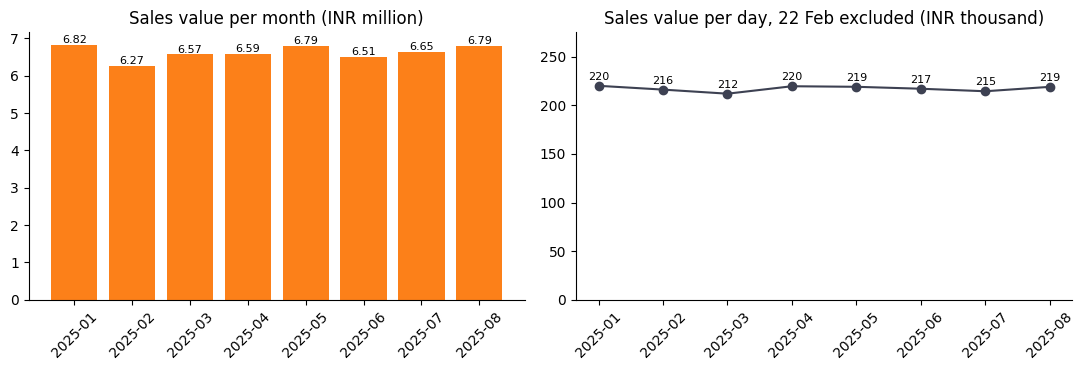

,sales,days,sales_per_day,MoM % (total),MoM % (per day)
Year_Month,,,,,
2025-01,6823981.3,31,220128.4,NaN,NaN
2025-02,6268106.7,27,216223.1,-8.1,-1.8
2025-03,6572738.2,31,212023.8,4.9,-1.9
2025-04,6590449.0,30,219681.6,0.3,3.6
2025-05,6792621.4,31,219116.8,3.1,-0.3
2025-06,6513676.2,30,217122.5,-4.1,-0.9
2025-07,6650268.5,31,214524.8,2.1,-1.2
2025-08,6790899.2,31,219061.3,2.1,2.1


In [ ]:
total = df.groupby('Year_Month').agg(sales=('Price_INR', 'sum'), records=('order_id', 'count'))
per_day = ex.groupby('Year_Month').agg(sales_ex=('Price_INR', 'sum'), days=('Order_Date', 'nunique'))

months = total.join(per_day)
months['sales_per_day'] = months['sales_ex'] / months['days']
months['MoM % (total)'] = months['sales'].pct_change() * 100
months['MoM % (per day)'] = months['sales_per_day'].pct_change() * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].bar(months.index, months['sales'] / 1e6, color=ORANGE)
ax[0].set_title('Sales value per month (INR million)')
for i, v in enumerate(months['sales'] / 1e6):
    ax[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=8)

ax[1].plot(months.index, months['sales_per_day'] / 1e3, marker='o', color=GREY)
ax[1].set_ylim(0, months['sales_per_day'].max() / 1e3 * 1.25)
ax[1].set_title('Sales value per day, 22 Feb excluded (INR thousand)')
for i, v in enumerate(months['sales_per_day'] / 1e3):
    ax[1].text(i, v + 6, f'{v:.0f}', ha='center', fontsize=8)

for a in ax:
    a.tick_params(axis='x', rotation=45)
save_chart('01_monthly_sales')

months[['sales', 'days', 'sales_per_day', 'MoM % (total)', 'MoM % (per day)']].round(1)

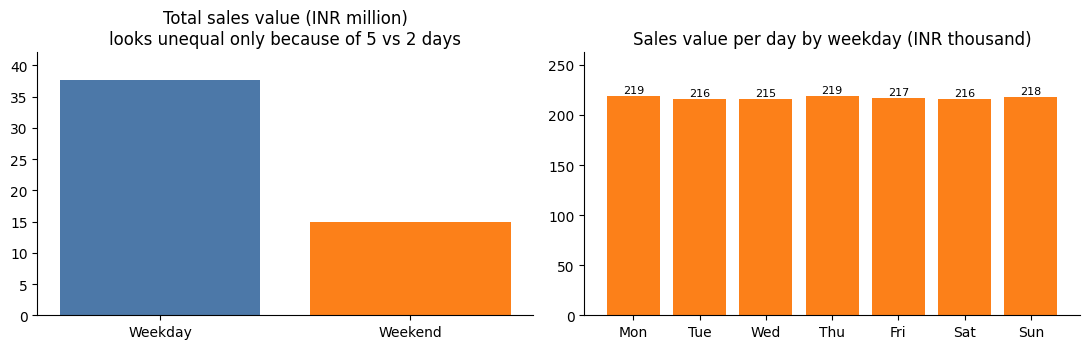

,sales,records,days,avg_item_price,sales_per_day,records_per_day
Day_Type,,,,,,
Weekday,37587840.1,139999,173,268.5,217270.8,809.2
Weekend,14984816.1,55853,69,268.3,217171.2,809.5


In [ ]:
daytype = ex.groupby('Day_Type').agg(sales=('Price_INR', 'sum'),
                                     records=('order_id', 'count'),
                                     days=('Order_Date', 'nunique'),
                                     avg_item_price=('Price_INR', 'mean'))
daytype['sales_per_day'] = daytype['sales'] / daytype['days']
daytype['records_per_day'] = daytype['records'] / daytype['days']

dow = ex.groupby(['Day_Number', 'Day_of_Week']).agg(sales=('Price_INR', 'sum'),
                                                    days=('Order_Date', 'nunique')).reset_index()
dow['sales_per_day'] = dow['sales'] / dow['days']

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].bar(daytype.index, daytype['sales'] / 1e6, color=[BLUE, ORANGE])
ax[0].set_ylim(0, daytype['sales'].max() / 1e6 * 1.12)
ax[0].set_title('Total sales value (INR million)\nlooks unequal only because of 5 vs 2 days')

ax[1].bar(dow['Day_of_Week'].str[:3], dow['sales_per_day'] / 1e3, color=ORANGE)
ax[1].set_ylim(0, dow['sales_per_day'].max() / 1e3 * 1.2)
ax[1].set_title('Sales value per day by weekday (INR thousand)')
for i, v in enumerate(dow['sales_per_day'] / 1e3):
    ax[1].text(i, v + 3, f'{v:.0f}', ha='center', fontsize=8)

save_chart('02_weekday_vs_weekend')
daytype.round(1)

In [ ]:
qt = ex.groupby('Quarter').agg(sales=('Price_INR', 'sum'), days=('Order_Date', 'nunique'))
qt['sales_per_day'] = qt['sales'] / qt['days']
qt.index = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Aug only)']

print('Q3 total is lower only because it has 62 days instead of about 90.')
qt.round(0)

Q3 total is lower only because it has 62 days instead of about 90.


,sales,days,sales_per_day
Q1 (Jan-Mar),19234742.0,89,216121.0
Q2 (Apr-Jun),19896747.0,91,218646.0
Q3 (Jul-Aug only),13441168.0,62,216793.0


## 4. Geography

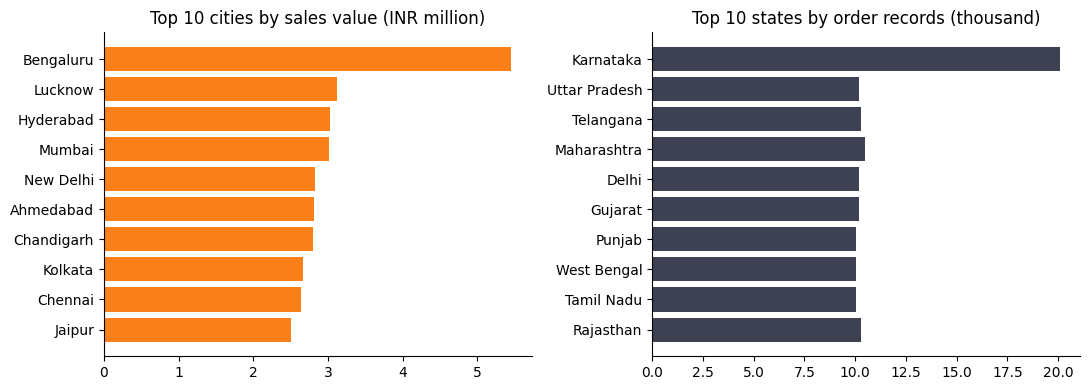

,sales,records,avg_item_price,share_of_sales_%
City,,,,
Bengaluru,5455887.7,20072,271.8,10.3
Lucknow,3117359.6,10192,305.9,5.9
Hyderabad,3021656.6,10308,293.1,5.7
Mumbai,3015573.4,10507,287.0,5.7
New Delhi,2829180.6,10191,277.6,5.3
Ahmedabad,2815536.3,10175,276.7,5.3
Chandigarh,2804991.8,10060,278.8,5.3
Kolkata,2662213.8,10044,265.1,5.0
Chennai,2642594.6,10042,263.2,5.0


In [ ]:
def summarise(grouped):
    out = grouped.agg(sales=('Price_INR', 'sum'),
                      records=('order_id', 'count'),
                      avg_item_price=('Price_INR', 'mean'))
    out['share_of_sales_%'] = out['sales'] / sales * 100
    return out.sort_values('sales', ascending=False)

city = summarise(df.groupby('City'))
state = summarise(df.groupby('State'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

top = city.head(10).iloc[::-1]
ax[0].barh(top.index, top['sales'] / 1e6, color=ORANGE)
ax[0].set_title('Top 10 cities by sales value (INR million)')

top = state.head(10).iloc[::-1]
ax[1].barh(top.index, top['records'] / 1e3, color=GREY)
ax[1].set_title('Top 10 states by order records (thousand)')

save_chart('03_geography')
city.head(10).round(1)

## 5. Restaurants
`Restaurant_Name` is a brand name, so a chain like KFC covers many outlets.

Top 5 restaurants = 25.4% of sales value, top 10 = 34.2%
36 of 993 restaurants make up half of it


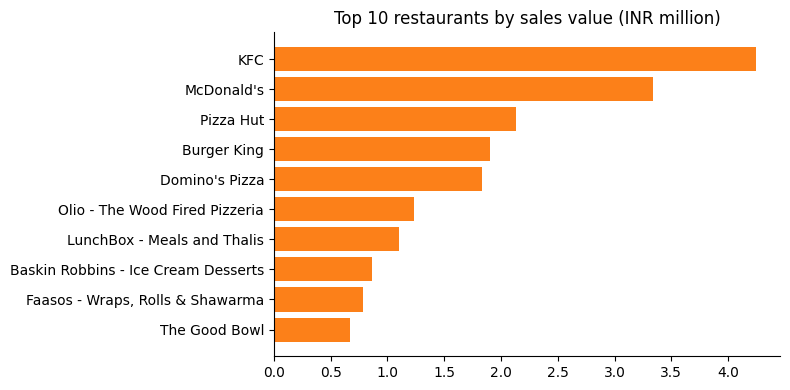

,sales,records,share_of_sales_%,avg_item_price,weighted_rating,locations
Restaurant_Name,,,,,,
KFC,4245461.78,12957,8.01,327.66,4.31,78
McDonald's,3342455.58,13528,6.31,247.08,4.44,45
Pizza Hut,2133265.69,6529,4.02,326.74,4.19,68
Burger King,1900518.09,7115,3.59,267.11,4.36,49
Domino's Pizza,1832985.32,5489,3.46,333.94,4.38,27
Olio - The Wood Fired Pizzeria,1232731.00,3239,2.33,380.59,4.26,36
LunchBox - Meals and Thalis,1101141.00,4700,2.08,234.29,4.38,24
Baskin Robbins - Ice Cream Desserts,860591.94,4197,1.62,205.05,4.64,36
"Faasos - Wraps, Rolls & Shawarma",780215.00,3256,1.47,239.62,4.34,24


In [ ]:
rated_w = rated.assign(w=rated['Rating'] * rated['Rating_Count'])
by_rest = rated_w.groupby('Restaurant_Name')
weighted_rating = (by_rest['w'].sum() / by_rest['Rating_Count'].sum()).rename('weighted_rating')

# names are case-sensitive here (993). SQL counts 984 because it ignores case
rest = summarise(df.groupby('Restaurant_Name')).join(weighted_rating)
rest = rest.join(df.groupby('Restaurant_Name')['Location'].nunique().rename('locations'))
rest['cum_share_%'] = rest['share_of_sales_%'].cumsum()

top5 = rest['share_of_sales_%'].head(5).sum()
top10 = rest['share_of_sales_%'].head(10).sum()
half = int((rest['cum_share_%'] < 50).sum() + 1)
print(f'Top 5 restaurants = {top5:.1f}% of sales value, top 10 = {top10:.1f}%')
print(f'{half} of {len(rest)} restaurants make up half of it')

fig, ax = plt.subplots(figsize=(8, 4))
top = rest.head(10).iloc[::-1]
ax.barh(top.index, top['sales'] / 1e6, color=ORANGE)
ax.set_title('Top 10 restaurants by sales value (INR million)')
save_chart('04_top_restaurants')

rest.head(10)[['sales', 'records', 'share_of_sales_%', 'avg_item_price', 'weighted_rating', 'locations']].round(2)

## 6. Prices

count    197401.0
mean        268.5
std         219.2
min           1.0
25%         139.0
50%         229.0
75%         329.0
95%         614.9
99%        1100.0
max        8000.0


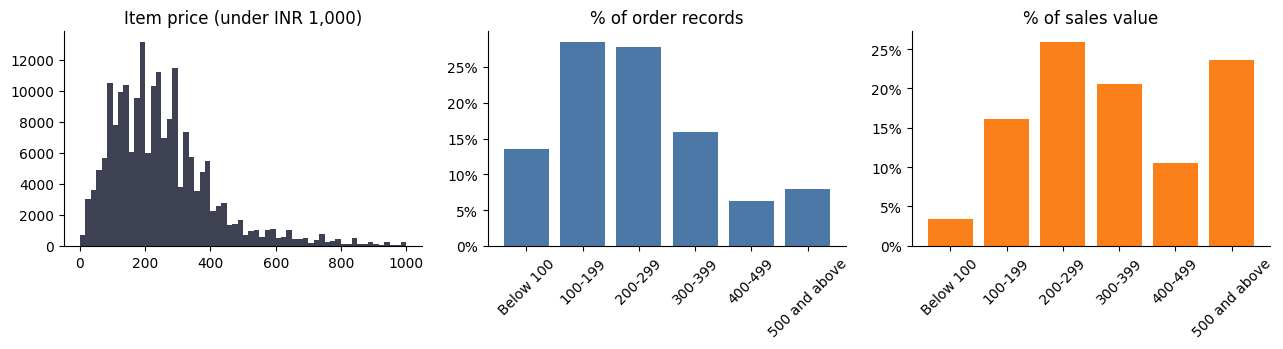

,records,sales,records_%,sales_%
Price_Range,,,,
Below 100,26795,1801638.2,13.6,3.4
100-199,56368,8522965.2,28.6,16.1
200-299,54773,13753514.9,27.7,25.9
300-399,31276,10884983.2,15.8,20.5
400-499,12492,5549656.5,6.3,10.5
500 and above,15697,12489982.5,8.0,23.6


In [ ]:
price = df['Price_INR']
print(price.describe(percentiles=[.25, .5, .75, .95, .99]).round(1).to_string())

# buckets: low <= price < high
edges = [0, 100, 200, 300, 400, 500, np.inf]
labels = ['Below 100', '100-199', '200-299', '300-399', '400-499', '500 and above']
df['Price_Range'] = pd.cut(df['Price_INR'], edges, labels=labels, right=False)

bucket = df.groupby('Price_Range', observed=True).agg(records=('order_id', 'count'),
                                                      sales=('Price_INR', 'sum'))
bucket['records_%'] = bucket['records'] / n * 100
bucket['sales_%'] = bucket['sales'] / sales * 100

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].hist(price[price < 1000], bins=60, color=GREY)
ax[0].set_title('Item price (under INR 1,000)')

ax[1].bar(bucket.index.astype(str), bucket['records_%'], color=BLUE)
ax[1].set_title('% of order records')

ax[2].bar(bucket.index.astype(str), bucket['sales_%'], color=ORANGE)
ax[2].set_title('% of sales value')

for a in ax[1:]:
    a.tick_params(axis='x', rotation=45)
    a.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

save_chart('05_prices')
bucket.round(1)

## 7. Ratings
A rating only means something if there are reviews behind it. That is why the cleaning step blanked the default values.

Rows with zero reviews: 79,094 in the raw file, 94.9% of them show exactly 4.4


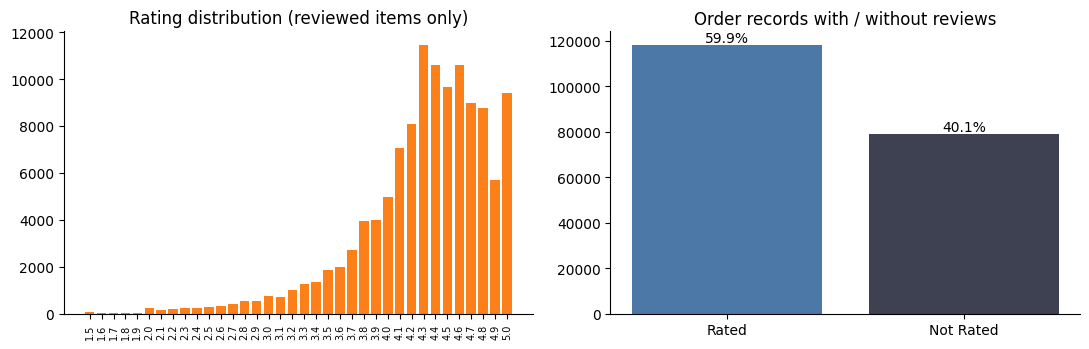

In [ ]:
zero = raw[raw['Rating_Count'] == '0']
share_44 = (pd.to_numeric(zero['Rating']) == 4.4).mean()
print(f'Rows with zero reviews: {len(zero):,} in the raw file, {share_44:.1%} of them show exactly 4.4')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

counts = rated['Rating'].round(1).value_counts().sort_index()
ax[0].bar(counts.index.astype(str), counts.values, color=ORANGE)
ax[0].set_title('Rating distribution (reviewed items only)')
ax[0].tick_params(axis='x', rotation=90, labelsize=7)

status = df['Rating_Status'].value_counts()
ax[1].bar(status.index, status.values, color=[BLUE, GREY])
ax[1].set_title('Order records with / without reviews')
for i, v in enumerate(status.values):
    ax[1].text(i, v, f'{v / n:.1%}', ha='center', va='bottom')

save_chart('06_ratings')

In [ ]:
by_tier = rated.groupby('Price_Category').agg(records=('Rating', 'size'),
                                              avg_rating=('Rating', 'mean')).loc[['Low', 'Medium', 'High']]
by_tier['share_with_reviews_%'] = (df.groupby('Price_Category')['Rating_Status']
                                     .apply(lambda s: (s == 'Rated').mean() * 100)
                                     .loc[by_tier.index])

corr = rated['Price_INR'].corr(rated['Rating'])
print('price vs rating correlation (reviewed items):', round(corr, 3))
by_tier.round(2)

price vs rating correlation (reviewed items): 0.028


,records,avg_rating,share_with_reviews_%
Price_Category,,,
Low,41346,4.31,63.46
Medium,40762,4.29,61.94
High,36213,4.32,54.51


In [ ]:
# average rating by city (only cities with enough reviewed rows)
city_rating = rated.groupby('City').agg(rated_records=('Rating', 'size'), avg_rating=('Rating', 'mean'))
city_rating = city_rating[city_rating['rated_records'] >= 500].sort_values('avg_rating')

print(f'{len(city_rating)} cities with 500+ reviewed records. 3 lowest and 3 highest:')
pd.concat([city_rating.head(3), city_rating.tail(3)]).round(2)

28 cities with 500+ reviewed records. 3 lowest and 3 highest:


,rated_records,avg_rating
City,,
Srinagar,2975,4.10
Gangtok,679,4.16
Patna,2364,4.18
Kolkata,6859,4.42
Aizawl,1022,4.43
Kochi,3352,4.46


## 8. The 22 Feb anomaly
It stays in the data, is flagged, and is left out of per-day numbers. I don't know the cause: it could be a real event or a data collection effect.

22 Feb rows vs usual rows per day, by city (top 3):
City
Bengaluru    10.2
Gangtok       1.9
Panaji        1.4
all other cities: 1.00x their usual level (median)
next-highest Bengaluru day: 2025-02-16 with 226 rows (normal is about 81)
it is not flagged because all cities together stay under the 1.5x rule


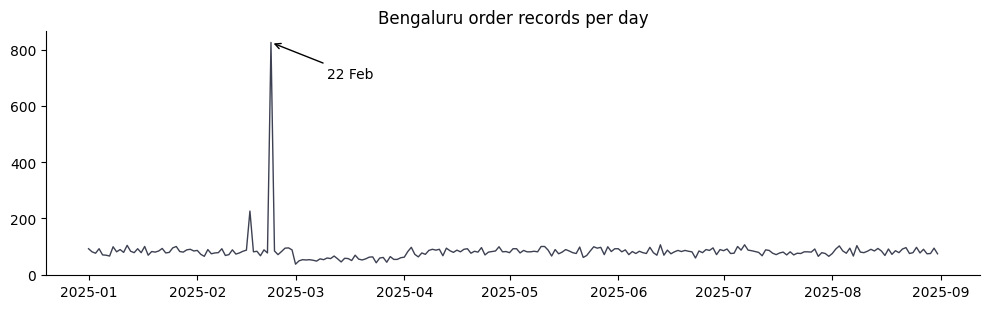

,22 Feb,typical day
rows,1549.0,810.0
median price (INR),240.0,229.0
not rated (%),34.4,40.1
distinct restaurants,361.0,337.0


In [ ]:
city_day = df.groupby(['Order_Date', 'City']).size().unstack(fill_value=0)
typical = city_day.drop(anomaly_days).median()
spike = (city_day.loc[anomaly_days[0]] / typical).sort_values(ascending=False)

print('22 Feb rows vs usual rows per day, by city (top 3):')
print(spike.head(3).round(1).to_string())
print(f'all other cities: {spike.iloc[1:].median():.2f}x their usual level (median)')

on_day = df[df['Is_Anomaly_Day']]
other = df[~df['Is_Anomaly_Day']]
compare = pd.DataFrame({
    '22 Feb': [len(on_day), on_day['Price_INR'].median(),
               (on_day['Rating_Status'] == 'Not Rated').mean() * 100,
               on_day['Restaurant_Name'].nunique()],
    'typical day': [other.groupby('Order_Date').size().median(), other['Price_INR'].median(),
                    (other['Rating_Status'] == 'Not Rated').mean() * 100,
                    other.groupby('Order_Date')['Restaurant_Name'].nunique().median()],
}, index=['rows', 'median price (INR)', 'not rated (%)', 'distinct restaurants'])

blr = city_day['Bengaluru'].drop(anomaly_days)
print(f'next-highest Bengaluru day: {blr.idxmax().date()} with {blr.max()} rows (normal is about {blr.median():.0f})')
print('it is not flagged because all cities together stay under the 1.5x rule')

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(city_day.index, city_day['Bengaluru'], color=GREY, lw=1)
ax.set_title('Bengaluru order records per day')
ax.annotate('22 Feb', xy=(anomaly_days[0], city_day.loc[anomaly_days[0], 'Bengaluru']),
            xytext=(pd.Timestamp('2025-03-10'), 700), arrowprops=dict(arrowstyle='->'))
save_chart('07_anomaly_bengaluru')

compare.round(1)

## 9. Food type from SQL (optional)
Veg / Non-Veg is worked out in `01_data_cleaning.sql`, not here. If you exported `vw_swiggy_analytics` to CSV, this cell checks it against the pandas data. If the file is missing, it just skips.

In [ ]:
view_csv = None
for p in ['vw_swiggy_analytics.csv', 'data/analytics/vw_swiggy_analytics.csv']:
    if os.path.exists(p):
        view_csv = p
        break

if view_csv is None:
    print('vw_swiggy_analytics.csv not found, skipping this part')
else:
    v = pd.read_csv(view_csv)
    print(f'rows: view {len(v):,} vs pandas {n:,}')
    print(f"sales value: view {v['Price_INR'].sum():,.2f} vs pandas {sales:,.2f}")

    food = v.groupby('Food_Type').agg(records=('Price_INR', 'size'), sales=('Price_INR', 'sum'))
    food['records_%'] = food['records'] / len(v) * 100
    print(food.round(1))

vw_swiggy_analytics.csv not found, skipping this part


## 10. Export
`swiggy_clean_python.csv` is the cleaned record-level data. `daily_sales.csv` has one row per day and is meant for the forecasting script.

In [ ]:
export_cols = ['order_id', 'Order_Date', 'State', 'City', 'Location', 'Restaurant_Name',
               'Category', 'Dish_Name', 'Price_INR', 'Rating', 'Rating_Count', 'Rating_Status',
               'Price_Category', 'Year_Month', 'Quarter', 'Week_Number', 'Day_of_Week',
               'Day_Type', 'Is_Anomaly_Day']
df[export_cols].to_csv('data/analytics/swiggy_clean_python.csv', index=False)

daily = df.groupby('Order_Date').agg(y=('Price_INR', 'sum'), orders=('order_id', 'count')).reset_index()
daily = daily.rename(columns={'Order_Date': 'ds'})
daily['aov'] = daily['y'] / daily['orders']
daily['is_anomaly'] = daily['ds'].isin(anomaly_days)
daily.to_csv('data/analytics/daily_sales.csv', index=False)

print(f'saved swiggy_clean_python.csv ({len(df):,} rows) and daily_sales.csv ({len(daily)} days)')

saved swiggy_clean_python.csv (197,401 rows) and daily_sales.csv (243 days)


## 11. Forecast check
Question: can a model predict daily sales better than a simple average? I only try simple baselines, because the daily series looks flat (no trend, no weekday effect), so a complex model has little to learn.

Method: rolling origin. Train on the days before a cut-off, predict the next 30 days, score, then move the cut-off forward 14 days and repeat. 22 Feb is scaled down to a normal day for training and skipped when scoring.

In [ ]:
# 22 Feb has about twice the normal rows. For TRAINING scale it down to a normal day
median_orders = daily['orders'].median()
daily['y_train'] = daily['y']
daily.loc[daily['is_anomaly'], 'y_train'] = (daily['y'] * median_orders / daily['orders'])[daily['is_anomaly']]

H = 30  # forecast 30 days ahead

# each model gets the history (numpy array) and returns H predictions
def naive(hist, dates):
    return np.repeat(hist[-1], H)

def mean_all(hist, dates):
    return np.repeat(hist.mean(), H)

def ma7(hist, dates):
    return np.repeat(hist[-7:].mean(), H)

def ma14(hist, dates):
    return np.repeat(hist[-14:].mean(), H)

def ma28(hist, dates):
    return np.repeat(hist[-28:].mean(), H)

def seasonal_naive(hist, dates):
    return np.tile(hist[-7:], H // 7 + 1)[:H]

def weekday_profile(hist, dates):
    # average of each weekday over the last 8 weeks
    last = pd.DataFrame({'dow': dates[-56:].dayofweek, 'y': hist[-56:]})
    avg = last.groupby('dow')['y'].mean()
    future = pd.date_range(dates[-1] + pd.Timedelta(days=1), periods=H)
    return avg.reindex(future.dayofweek).values

models = {
    'Naive (last day)': naive,
    'Mean of all history': mean_all,
    'Moving avg 7d': ma7,
    'Moving avg 14d': ma14,
    'Moving avg 28d': ma28,
    'Seasonal naive (7d)': seasonal_naive,
    'Weekday profile (8 weeks)': weekday_profile,
}

In [ ]:
# rolling origin backtest
fold_rows = []
for origin in range(60, len(daily) - H + 1, 14):
    train = daily.iloc[:origin]
    test = daily.iloc[origin:origin + H]
    keep = ~test['is_anomaly'].values          # do not score 22 Feb
    actual = test['y'].values[keep]

    for name, model in models.items():
        pred = model(train['y_train'].values, pd.DatetimeIndex(train['ds']))[keep]
        err = actual - pred
        fold_rows.append({
            'model': name,
            'origin': train['ds'].iloc[-1].date(),
            'MAE': np.abs(err).mean(),
            'MAPE': np.mean(np.abs(err / actual)) * 100,
            'WAPE': np.abs(err).sum() / actual.sum() * 100,
        })

folds = pd.DataFrame(fold_rows)
folds.to_csv('data/analytics/forecast_folds.csv', index=False)

n_folds = folds['origin'].nunique()
print(f'{n_folds} backtest folds, {H}-day horizon')
folds.head(7)

11 backtest folds, 30-day horizon


,model,origin,MAE,MAPE,WAPE
0,Naive (last day),2025-03-01,9201.365333,4.253654,4.336270
1,Mean of all history,2025-03-01,9881.238060,4.773312,4.656669
2,Moving avg 7d,2025-03-01,8196.828571,3.845535,3.862868
3,Moving avg 14d,2025-03-01,9266.439496,4.451249,4.366937
4,Moving avg 28d,2025-03-01,9249.545558,4.442399,4.358975
5,Seasonal naive (7d),2025-03-01,9580.149000,4.465536,4.514777
6,Weekday profile (8 weeks),2025-03-01,10095.562215,4.876105,4.757672


In [ ]:
summary = folds.groupby('model').agg(MAE=('MAE', 'mean'), MAPE=('MAPE', 'mean'),
                                     WAPE=('WAPE', 'mean'), WAPE_std=('WAPE', 'std'))
summary = summary.sort_values('WAPE').round(2)
summary.to_csv('data/analytics/forecast_summary.csv')
summary

,MAE,MAPE,WAPE,WAPE_std
model,,,,
Mean of all history,8467.00,3.92,3.90,0.54
Moving avg 28d,8645.86,3.99,3.98,0.56
Moving avg 14d,8772.30,4.05,4.04,0.65
Moving avg 7d,8897.80,4.10,4.10,0.78
Weekday profile (8 weeks),9022.57,4.17,4.15,0.62
Seasonal naive (7d),11488.36,5.29,5.28,0.80
Naive (last day),12099.86,5.55,5.57,2.36


Best: Mean of all history (WAPE 3.9%)
Gap to "mean of all history": 0.00 percentage points
The gap is small. The data is flat, so a plain average is about as good as any model.


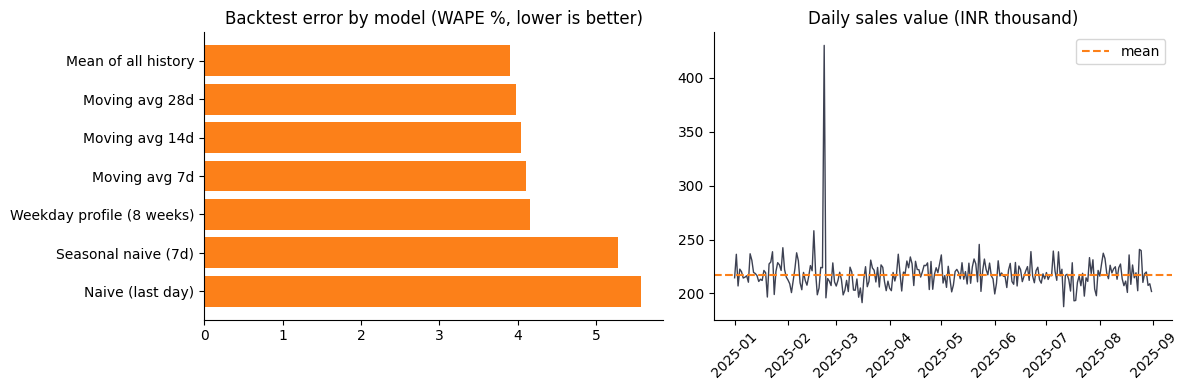

saved: forecast_folds.csv, forecast_summary.csv, forecast_summary.md, figures/08_forecast_backtest.png


In [ ]:
# is the best model clearly better than just using the average?
best = summary.index[0]
gap = summary.loc['Mean of all history', 'WAPE'] - summary.loc[best, 'WAPE']
print(f'Best: {best} (WAPE {summary.loc[best, "WAPE"]}%)')
print(f'Gap to "mean of all history": {gap:.2f} percentage points')

if gap < 1:
    verdict = 'The gap is small. The data is flat, so a plain average is about as good as any model.'
else:
    verdict = f'{best} beats the plain average by {gap:.1f} points, so there is some pattern to use.'
print(verdict)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].barh(summary.index[::-1], summary['WAPE'][::-1], color=ORANGE)
ax[0].set_title('Backtest error by model (WAPE %, lower is better)')

ax[1].plot(daily['ds'], daily['y'] / 1e3, color=GREY, lw=1)
ax[1].axhline(daily['y_train'].mean() / 1e3, color=ORANGE, ls='--', label='mean')
ax[1].set_title('Daily sales value (INR thousand)')
ax[1].legend()
ax[1].tick_params(axis='x', rotation=45)

save_chart('08_forecast_backtest')

with open('data/analytics/forecast_summary.md', 'w') as f:
    f.write(f'# Forecast check ({n_folds} folds, {H}-day horizon)\n\n')
    f.write(summary.to_string() + '\n\n' + verdict + '\n')
print('saved: forecast_folds.csv, forecast_summary.csv, forecast_summary.md, figures/08_forecast_backtest.png')

## Key findings
*(Jan-Aug 2025, 22 Feb left out of every per-day figure. Numbers are from my run on the real file.)*

1. **Scale.** 197,401 order records, INR 5.30 Cr sales value, 28 cities, average item price INR 268.50 (median INR 229).
2. **Flat over time.** Sales per day stayed between INR 212,024 and INR 220,128 in every month, no growth and no decline. February's -8.1% month-over-month drop is mostly a shorter month. Per day it is -1.8%.
3. **No weekday/weekend effect.** INR 217,271 per weekday vs INR 217,171 per weekend day. Weekends only look smaller in totals because there are 2 of them against 5.
4. **Bengaluru is the biggest market:** INR 5.46M (10.3% of sales value). Even without 22 Feb it has 1.8x the order records of the next city.
5. **A few brands dominate.** The top 5 restaurants make up 25.4% of sales value, KFC alone 8.0%. 36 of 993 restaurant names account for half.
6. **Cheap items are many, expensive items are valuable.** Items of INR 500 or more are 8.0% of records but 23.6% of sales value.
7. **Ratings.** Only 59.9% of records have reviews. Reviewed items average 4.31 (4.36 weighted by review count). Price and rating are almost unrelated (correlation 0.03).
8. **22 Feb 2025.** Bengaluru has about 10x its normal volume that day while the other cities are normal. The cause is unknown, so the day is flagged and kept out of per-day trends.

## Limitations
- **Eight months only.** No full year, so nothing about yearly seasonality or Q4.
- **A row is a dish line item, not a verified order.** Sales value is not Swiggy's revenue.
- **40% of ratings are missing.** Rating results describe reviewed items only.
- **Descriptive only.** These are patterns in one dataset, not causes.
- **Veg/Non-Veg and cuisine labels** come from keyword rules in SQL and a large share is Unclassified, so treat them as approximate.
- **Forecast:** only 11 backtest folds on 8 months of data, so the ranking of close models is not reliable. No yearly seasonality can be tested.
- **16 Feb** has a smaller Bengaluru bump that is not flagged and stays in the data.